In [2]:
import os
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import HandLandmarker
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from collections import Counter
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch
import random

seed = 42

random.seed(seed)

np.random.seed(seed)
torch.manual_seed(seed)

torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True # make results constant
torch.backends.cudnn.benchmark = False

In [ ]:
# ---------- Paths ----------
DATASET_PATH = "./asl_dataset/ImagesDataset"  
OUTPUT_PATH = "landmarks_dataset"
os.makedirs(OUTPUT_PATH, exist_ok=True)

# ---------- MediaPipe Setup ----------
model_path = "D:/DEPI/Final/project/asl_dataset/hand_landmarker.task"

BaseOptions = mp.tasks.BaseOptions
HandLandmarkerOptions = vision.HandLandmarkerOptions
RunningMode = vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=RunningMode.IMAGE,
    num_hands=1
)

detector = HandLandmarker.create_from_options(options)

# ---------- Extract Landmarks ----------
def extract_landmarks(image_path):
    image = cv2.imread(image_path)
    if image is None:
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

    result = detector.detect(mp_image)

    if not result.hand_landmarks:
        return None

    hand = result.hand_landmarks[0]

    # ===== safety check =====
    if len(hand) != 21:
        return None

    landmarks = []

    for lm in hand:
        landmarks.extend([lm.x, lm.y, lm.z])

    landmarks = np.array(landmarks)

    if len(landmarks) != 63:
        return None

    landmarks = landmarks.reshape(21, 3)

    # ===== normalization =====

    # center on wrist
    landmarks = landmarks - landmarks[0]

    # scale normalize (safe)
    scale = np.max(np.abs(landmarks))
    if scale < 1e-6:
        return None

    landmarks = landmarks / scale

    return landmarks.flatten(
        
    )# ---------- Load Dataset ----------
x = []
y = []

print("📂 Reading dataset...")

for label in os.listdir(DATASET_PATH):
    label_path = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(label_path):
        continue

    for file in os.listdir(label_path):
        if file.endswith((".jpg", ".png")):
            file_path = os.path.join(label_path, file)

            landmarks = extract_landmarks(file_path)

            if landmarks is not None:
                x.append(landmarks)
                y.append(label)

# تحويل لـ numpy
x = np.array(x)
y = np.array(y)

print("✅ Total samples:", len(x))

# ---------- Split (IMPORTANT) ----------
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(x_train))
print("Test size:", len(x_test))

# ---------- Save as .npy ----------
np.save(os.path.join(OUTPUT_PATH, "x_train.npy"), x_train)
np.save(os.path.join(OUTPUT_PATH, "x_test.npy"), x_test)
np.save(os.path.join(OUTPUT_PATH, "y_train.npy"), y_train)
np.save(os.path.join(OUTPUT_PATH, "y_test.npy"), y_test)

print("💾 Saved successfully!")

📂 Reading dataset...
✅ Total samples: 35412
Train size: 28329
Test size: 7083
💾 Saved successfully!


In [3]:
import numpy as np

x_train = np.load("landmarks_dataset/x_train.npy")
x_test  = np.load("landmarks_dataset/x_test.npy")
y_train = np.load("landmarks_dataset/y_train.npy")
y_test  = np.load("landmarks_dataset/y_test.npy")

print("Loaded successfully ✅")

import numpy as np

def augment_landmarks(x):
    x = x.copy()
    
    # 1. Noise بسيط
    noise = np.random.normal(0, 0.01, x.shape)
    x += noise

    # 2. Scaling
    scale = np.random.normal(1.0, 0.05)
    x *= scale

    # 3. Translation (تحريك بسيط)
    shift = np.random.normal(0, 0.02, x.shape)
    x += shift

    return x

augmented = []

for sample in x_train:
    augmented.append(augment_landmarks(sample))

x_train_aug = np.array(augmented)

# دمج الأصل + augmented
x_train = np.concatenate([x_train, x_train_aug])
y_train = np.concatenate([y_train, y_train])


Loaded successfully ✅


In [4]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test  = encoder.transform(y_test)

import joblib
joblib.dump(encoder, "label_encoder.joblib")

['label_encoder.joblib']

In [5]:
# new
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [ ]:
#from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()

#x_train = scaler.fit_transform(x_train)
#x_val   = scaler.transform(x_val)
#x_test  = scaler.transform(x_test)

In [ ]:
#joblib.dump(scaler, "scaler.joblib")

['scaler.joblib']

In [6]:
x_train = x_train.reshape(-1, 1, 63).astype("float32")
x_val   = x_val.reshape(-1, 1, 63).astype("float32")
x_test  = x_test.reshape(-1, 1, 63).astype("float32")

In [7]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train = torch.tensor(x_train)
X_val   = torch.tensor(x_val)
X_test  = torch.tensor(x_test)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=32)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=32)

In [8]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train.numpy()),
    y=y_train.numpy()
)

weights = torch.tensor(weights, dtype=torch.float32)

In [9]:
import torch.nn as nn

class ASLModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 64, 3, padding=1)
        self.bn1   = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(64, 128, 3, padding=1)
        self.bn2   = nn.BatchNorm1d(128)

        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.LazyLinear(128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))

        x = x.view(x.size(0), -1)

        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)

        return x


model = ASLModel(num_classes=len(np.unique(y_train)))

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_loss = float('inf')
patience = 1
counter = 0

for epoch in range(15):
    model.train()
    train_loss = 0
    correct_train = 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == y_batch).sum().item()

    train_acc = correct_train / len(x_train)

    # ===== Validation =====
    model.eval()
    val_loss = 0
    correct_val = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct_val += (preds == y_batch).sum().item()

    val_acc = correct_val / len(x_val)

    # ===== Save metrics =====
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-"*40)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping 🔴")
            break

Epoch 1
Train Loss: 774.8264 | Train Acc: 0.8204
Val   Loss: 41.4059 | Val   Acc: 0.9684
----------------------------------------
Epoch 2
Train Loss: 184.2822 | Train Acc: 0.9532
Val   Loss: 16.8932 | Val   Acc: 0.9884
----------------------------------------
Epoch 3
Train Loss: 130.5669 | Train Acc: 0.9675
Val   Loss: 15.8999 | Val   Acc: 0.9865
----------------------------------------
Epoch 4
Train Loss: 105.7463 | Train Acc: 0.9730
Val   Loss: 8.6384 | Val   Acc: 0.9927
----------------------------------------
Epoch 5
Train Loss: 94.8493 | Train Acc: 0.9762
Val   Loss: 7.3249 | Val   Acc: 0.9941
----------------------------------------
Epoch 6
Train Loss: 84.8163 | Train Acc: 0.9780
Val   Loss: 6.7156 | Val   Acc: 0.9944
----------------------------------------
Epoch 7
Train Loss: 73.2895 | Train Acc: 0.9816
Val   Loss: 4.8259 | Val   Acc: 0.9959
----------------------------------------
Epoch 8
Train Loss: 72.5779 | Train Acc: 0.9824
Val   Loss: 6.2359 | Val   Acc: 0.9944
----------

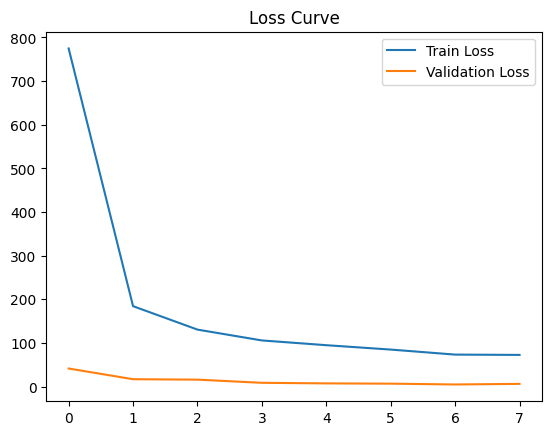

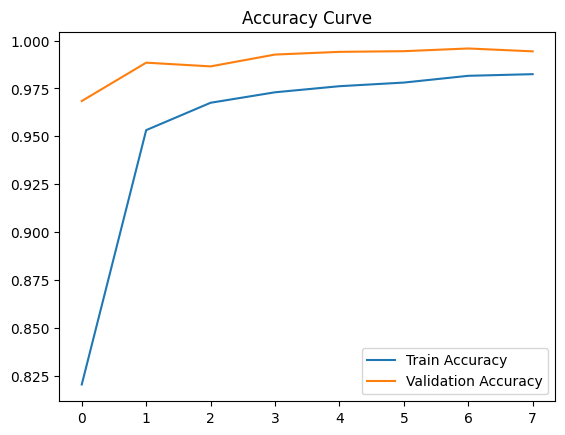

In [11]:
import matplotlib.pyplot as plt

# Loss
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

# Accuracy
plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [12]:
# Load best model
# calculate performance od model based on test set and prediction 

from sklearn.metrics import confusion_matrix
import torch

y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [13]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        outputs = model(x_batch)
        preds = torch.argmax(outputs, dim=1)

        total += y_batch.size(0)
        correct += (preds == y_batch).sum().item()

print("Test Accuracy:", correct / total * 100)

Test Accuracy: 99.98588168855005


In [15]:
model.eval()
torch.save(model.state_dict(), "asl_model.pth")


In [ ]:

#----------------------------------------------------------------

CONVERT FROM TENSORFLOW TO PYTHORCH

In [ ]:
#import torch
#from torch.utils.data import TensorDataset, DataLoader

# reshape (important)
#x_train = x_train.reshape(-1, 63, 1).astype("float32")
#x_test  = x_test.reshape(-1, 63, 1).astype("float32")

# to tensor
#X_train = torch.tensor(x_train)
#X_test  = torch.tensor(x_test)

#y_train = torch.tensor(y_train, dtype=torch.long)
#y_test  = torch.tensor(y_test, dtype=torch.long)

#train_dataset = TensorDataset(X_train, y_train)
#test_dataset  = TensorDataset(X_test, y_test)

#train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
#test_loader  = DataLoader(test_dataset, batch_size=32)

In [ ]:
#import torch.nn as nn
#import torch.nn.functional as F

#class ASLModel(nn.Module):
 #   def __init__(self, num_classes=36):
  #      super().__init__()
#
 #       self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3)
  #      self.pool = nn.MaxPool1d(2)
#
 #       self.conv2 = nn.Conv1d(64, 128, 3)

        # حساب تقريبي بعد pooling
  #      self.fc1 = nn.Linear(128 * 14, 128)
   #     self.dropout = nn.Dropout(0.5)
    #    self.fc2 = nn.Linear(128, num_classes)

    #def forward(self, x):
     #   x = x.permute(0, 2, 1)  # (batch, channel, seq)

       # x = F.relu(self.conv1(x))
      #  x = self.pool(x)

        #x = F.relu(self.conv2(x))
        #x = self.pool(x)

        #x = x.flatten(start_dim=1)

        #x = F.relu(self.fc1(x))
        #x = self.dropout(x)
        #x = self.fc2(x)

#        return x

In [ ]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#model = ASLModel().to(device)

#criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#epochs = 15

#for epoch in range(epochs):
 #   model.train()
  #  total_loss = 0

   # for x_batch, y_batch in train_loader:
    #    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

     #   optimizer.zero_grad()
      #  outputs = model(x_batch)

       # loss = criterion(outputs, y_batch)
        #loss.backward()
        #optimizer.step()

        #total_loss += loss.item()

   # print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

Epoch 1/15 | Loss: 1516.8466
Epoch 2/15 | Loss: 523.2836
Epoch 3/15 | Loss: 381.9084
Epoch 4/15 | Loss: 322.8444
Epoch 5/15 | Loss: 277.8281
Epoch 6/15 | Loss: 253.7272
Epoch 7/15 | Loss: 229.9415
Epoch 8/15 | Loss: 206.5820
Epoch 9/15 | Loss: 188.9010
Epoch 10/15 | Loss: 176.1802
Epoch 11/15 | Loss: 168.4415
Epoch 12/15 | Loss: 161.0973
Epoch 13/15 | Loss: 148.3313
Epoch 14/15 | Loss: 144.5594
Epoch 15/15 | Loss: 139.9415


In [ ]:
#model.eval()

#correct = 0
#total = 0

#with torch.no_grad():
 #   for x_batch, y_batch in test_loader:
  #      x_batch, y_batch = x_batch.to(device), y_batch.to(device)

   #     outputs = model(x_batch)
    #    _, predicted = torch.max(outputs, 1)

     #   total += y_batch.size(0)
      #  correct += (predicted == y_batch).sum().item()

#print("Accuracy:", correct / total * 100)

Accuracy: 99.81646195115064


In [ ]:
#def accuracy(model, dataloader, device):
 #   model.eval()
  #  correct = 0
   # total = 0

   # with torch.no_grad():
    #    for x_batch, y_batch in dataloader:
     #       x_batch, y_batch = x_batch.to(device), y_batch.to(device)

      #      outputs = model(x_batch)
       #     _, predicted = torch.max(outputs, 1)

        #    total += y_batch.size(0)
         #   correct += (predicted == y_batch).sum().item()

    #return 100 * correct / total

In [ ]:
#train_acc = accuracy(model, train_loader, device)
#print(f"Train Accuracy: {train_acc:.2f}%")

Train Accuracy: 99.82%


In [ ]:
#test_acc = accuracy(model, test_loader, device)
#print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 99.82%
